# Training a Deep Neural Network using CNN on CIFAR-10 and CIFAR-100

## Objective

Build and train a Convolutional Neural Network (CNN) for image classification on:
- CIFAR-10 dataset
- CIFAR-100 dataset

The goal is to:
- Understand CNN architecture
- Compare hyperparameters
- Find the best learning rate and weight decay
- Evaluate model performance

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Reproducibility

Set random seeds so experiments can be reproduced.

In [3]:
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset Configuration

CIFAR images have:
- 32 × 32 pixel resolution
- 3 color channels (RGB)

CIFAR-10:
- 10 classes
- 50,000 training images
- 10,000 test images

CIFAR-100:
- 100 classes
- 50,000 training images
- 10,000 test images

In [4]:
BATCH_SIZE = 128
NUM_WORKERS = 2

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

In [6]:
#Preprocessing for better and robust training - Adding Random crops, Horizontal Flips and Normalization

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [7]:
#Loading CIFAR-10 dataset

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [8]:
# Splitting the original CIFAR-10 training dataset into:
# - 80% training data (used to learn the model weights)
# - 20% validation data (used to evaluate and tune hyperparameters)

from torch.utils.data import random_split

# Calculate number of images for each split
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Randomly split the training dataset
# The validation set is taken from the original training data
train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# Check the size of each dataset
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Training samples: 40000
Validation samples: 10000
Test samples: 10000


In [9]:
# Creating DataLoaders to efficiently feed batches of images to the CNN

from torch.utils.data import DataLoader

# Number of images processed in one forward/backward pass
BATCH_SIZE = 128

# Number of CPU workers used to load data in parallel
NUM_WORKERS = 2

# Training DataLoader
# shuffle=True ensures the model sees images in a different order each epoch
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Validation DataLoader
# No shuffling because we are only evaluating the model
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Test DataLoader
# Used only for final model evaluation
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created successfully")

DataLoaders created successfully


## CNN Architecture

A Convolutional Neural Network (CNN) is a deep learning model designed for image classification. It learns important visual patterns automatically from images instead of requiring manual feature extraction.

The architecture consists of two parts:

### 1. Feature Extraction

The feature extractor uses repeated blocks of:

**Convolution → Batch Normalization → ReLU → Max Pooling**

- **Convolution (`Conv2d`)**: Applies learnable filters to detect patterns such as edges, textures and shapes.
- **Batch Normalization (`BatchNorm2d`)**: Normalizes intermediate activations to make training more stable and faster.
- **ReLU Activation**: Adds non-linearity, allowing the network to learn complex patterns.
- **Max Pooling (`MaxPool2d`)**: Reduces the spatial size of feature maps while keeping important information.

As the network becomes deeper, it learns more complex features.

### 2. Classifier

After feature extraction, the feature maps are flattened and passed through fully connected layers.

The classifier converts the learned features into class predictions.

For CIFAR-10, the final output layer produces 10 values, one for each class:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

The class with the highest output score is selected as the prediction.

This architecture allows the CNN to learn hierarchical features:
- early layers learn simple patterns like edges
- deeper layers learn object-level patterns

In [10]:
# Defining the CNN architecture

import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
# Creating CNN model for CIFAR-10

model = CNN(num_classes=10).to(device)

print("CNN model created successfully")

CNN model created successfully


In [12]:
# Test a single batch through the network

images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([128, 3, 32, 32])
Output shape: torch.Size([128, 10])


## Loss Function and Optimizer

The CNN learns by comparing its predictions with the actual labels.

The loss function measures how far the prediction is from the correct answer. During training, the goal is to minimize this loss.

Cross Entropy Loss is commonly used for multi-class classification problems because it compares the predicted class probabilities with the true class label.

The optimizer updates the model weights using the gradients calculated during backpropagation.

Adam optimizer combines adaptive learning rates with momentum-based updates, helping the model converge faster.

In [13]:
# Defining loss function and optimizer

import torch.optim as optim

# Cross entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()

# Hyperparameters
learning_rate = 0.001
weight_decay = 1e-4
epochs = 20

# Adam optimizer updates the CNN weights during training
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

print("Training setup complete")

Training setup complete


## Training the CNN

During training, the model learns by repeatedly seeing batches of images.

For each batch:
1. The images are passed through the CNN to generate predictions.
2. The loss function compares predictions with true labels.
3. Backpropagation calculates gradients.
4. The optimizer updates the model weights.

The model is evaluated on the validation set after each epoch to monitor performance and detect overfitting.

In [14]:
# Function to train the model for one epoch

def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss / len(loader), accuracy

In [15]:
# Function to evaluate the model on validation/test data

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    # Disable gradient calculation during evaluation
    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss / len(loader), accuracy

## Model Training

The CNN is trained for multiple epochs.

During each epoch:
- The model learns from the training dataset.
- The validation dataset is used to measure generalization performance.
- Training and validation accuracy are tracked to monitor learning and detect overfitting.

In [16]:
# Training loop

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/20] Train Loss: 1.6375 Train Acc: 39.30% Val Loss: 1.3146 Val Acc: 52.45%
Epoch [2/20] Train Loss: 1.3279 Train Acc: 51.82% Val Loss: 1.2409 Val Acc: 55.70%
Epoch [3/20] Train Loss: 1.1857 Train Acc: 57.45% Val Loss: 1.0172 Val Acc: 62.70%
Epoch [4/20] Train Loss: 1.1189 Train Acc: 60.24% Val Loss: 1.0182 Val Acc: 63.29%
Epoch [5/20] Train Loss: 1.0516 Train Acc: 62.88% Val Loss: 0.8959 Val Acc: 68.59%
Epoch [6/20] Train Loss: 1.0074 Train Acc: 64.86% Val Loss: 0.8890 Val Acc: 68.86%
Epoch [7/20] Train Loss: 0.9636 Train Acc: 66.23% Val Loss: 0.8714 Val Acc: 69.21%
Epoch [8/20] Train Loss: 0.9227 Train Acc: 67.64% Val Loss: 0.8539 Val Acc: 69.74%
Epoch [9/20] Train Loss: 0.9021 Train Acc: 68.58% Val Loss: 0.9149 Val Acc: 67.67%
Epoch [10/20] Train Loss: 0.8822 Train Acc: 69.34% Val Loss: 0.8551 Val Acc: 69.71%
Epoch [11/20] Train Loss: 0.8581 Train Acc: 70.08% Val Loss: 0.8382 Val Acc: 70.69%
Epoch [12/20] Train Loss: 0.8413 Train Acc: 70.79% Val Loss: 0.7519 Val Acc: 73.42%
E

## Model Evaluation on Test Data

After training is complete, the final model is evaluated on the test dataset.

The test dataset contains images that were not used during training or hyperparameter tuning. This gives an unbiased estimate of how well the model generalizes to unseen data.

During testing:
- The model is switched to evaluation mode.
- Gradient calculations are disabled since no learning occurs.
- Predictions are compared with the true labels to calculate test loss and accuracy.

The final test accuracy represents the model's performance on unseen CIFAR-10 images.

In [17]:
# Final evaluation on the test dataset

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 79.63%


## Hyperparameter Tuning

Hyperparameters are settings chosen before training begins. They control how the model learns.

For this experiment, we tune:

- Learning rate: controls the size of weight updates during optimization.
- Weight decay: controls regularization and helps prevent overfitting.

Different combinations are trained and compared using validation accuracy.

The configuration with the highest validation accuracy is selected as the best model.

In [18]:
def run_experiment(learning_rate, weight_decay, epochs=20):

    model = CNN(num_classes=10).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    for epoch in range(epochs):
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

    _, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    return val_acc, model

In [19]:
experiments = [
    {"lr": 0.001,  "weight_decay": 1e-4},   # Baseline
    {"lr": 0.0005, "weight_decay": 1e-4},   # Lower LR
    {"lr": 0.01,   "weight_decay": 1e-4},   # Higher LR
    {"lr": 0.001,  "weight_decay": 1e-3},   # Higher weight decay
    {"lr": 0.001,  "weight_decay": 0},      # No weight decay
    {"lr": 0.0005, "weight_decay": 1e-3},   # Lower LR + higher weight decay
]

results = []

for exp in experiments:

    acc, trained_model = run_experiment(
        exp["lr"],
        exp["weight_decay"]
    )

    results.append(
        {
            "learning_rate": exp["lr"],
            "weight_decay": exp["weight_decay"],
            "val_accuracy": acc
        }
    )

results

[{'learning_rate': 0.001, 'weight_decay': 0.0001, 'val_accuracy': 77.03},
 {'learning_rate': 0.0005, 'weight_decay': 0.0001, 'val_accuracy': 77.66},
 {'learning_rate': 0.01, 'weight_decay': 0.0001, 'val_accuracy': 65.45},
 {'learning_rate': 0.001, 'weight_decay': 0.001, 'val_accuracy': 77.3},
 {'learning_rate': 0.001, 'weight_decay': 0, 'val_accuracy': 77.97},
 {'learning_rate': 0.0005, 'weight_decay': 0.001, 'val_accuracy': 75.56}]

## Hyperparameter Tuning Results

Six combinations of learning rate and weight decay were tested.

| Experiment                      | Learning Rate | Weight Decay | Validation Accuracy | Expected Behaviour                  |
|----------------------------------|--------------|--------------|----------------------|---------------------------------------|
| Baseline                         | 0.001        | 0.0001       | 77.03                | Normal                                |
| Lower LR                         | 0.0005       | 0.0001       | 77.66                | More stable updates                   |
| Higher LR                        | 0.01         | 0.0001       | 65.45                | Faster but risk of instability        |
| Higher weight decay              | 0.001        | 0.001        | 77.30                | Stronger regularization               |
| No weight decay                  | 0.001        | 0            | 77.97                | Less regularization                   |
| Lower LR + higher weight decay   | 0.0005       | 0.001        | 75.56                | Slower, more regularized updates      |

The best performing configuration was:

- Learning Rate: 0.001
- Weight Decay: 0

The clearest result from this expanded search is the higher learning rate (0.01), which dropped validation accuracy to 65.45%, over 10 points below every other configuration. This confirms what the earlier three-experiment search couldn't show: a learning rate that large is too aggressive for this architecture, likely overshooting good minima rather than converging smoothly within 20 epochs.

Among the remaining five configurations, accuracy ranges from 75.56% to 77.97%, a spread of about 2.4 points, somewhat wider than the gap you'd expect from run-to-run noise alone, but driven mostly by one outlier rather than a clean trend. The lower learning rate combined with higher weight decay (75.56%) is the only one of the five that falls more than a point below the rest, which suggests that particular combination simply needs more than 20 epochs to converge, not that weight decay itself is harmful. Looking at weight decay in isolation, with learning rate held at 0.001, the baseline (1e-4), no decay, and 1e-3 decay all land within a point of each other (77.03%, 77.97%, 77.30%). Learning rate is what actually drove the result in this search, and only when pushed an order of magnitude higher than every other setting tried.

In [20]:
# Best hyperparameters found during tuning

learning_rate = 0.001
weight_decay = 0

## Final CIFAR-10 Model Training

After hyperparameter tuning, the best performing configuration is used to train the final model.

This model will be evaluated on the test dataset to measure its performance on unseen images.

In [21]:
# Train CIFAR-10 model using the best hyperparameters

learning_rate = 0.001
weight_decay = 0

final_model = CNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    final_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

final_train_losses = []
final_train_accuracies = []
final_val_losses = []
final_val_accuracies = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        final_model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        final_model,
        val_loader,
        criterion
    )

    final_train_losses.append(train_loss)
    final_train_accuracies.append(train_acc)
    final_val_losses.append(val_loss)
    final_val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/20] Train Acc: 39.28% Val Acc: 50.18%
Epoch [2/20] Train Acc: 51.99% Val Acc: 59.24%
Epoch [3/20] Train Acc: 57.45% Val Acc: 63.51%
Epoch [4/20] Train Acc: 61.01% Val Acc: 64.51%
Epoch [5/20] Train Acc: 63.30% Val Acc: 68.06%
Epoch [6/20] Train Acc: 65.25% Val Acc: 66.00%
Epoch [7/20] Train Acc: 66.88% Val Acc: 69.98%
Epoch [8/20] Train Acc: 68.14% Val Acc: 70.27%
Epoch [9/20] Train Acc: 68.83% Val Acc: 71.63%
Epoch [10/20] Train Acc: 69.95% Val Acc: 72.35%
Epoch [11/20] Train Acc: 70.94% Val Acc: 73.05%
Epoch [12/20] Train Acc: 71.26% Val Acc: 74.46%
Epoch [13/20] Train Acc: 72.33% Val Acc: 73.62%
Epoch [14/20] Train Acc: 72.87% Val Acc: 75.49%
Epoch [15/20] Train Acc: 73.83% Val Acc: 75.66%
Epoch [16/20] Train Acc: 74.18% Val Acc: 75.80%
Epoch [17/20] Train Acc: 74.66% Val Acc: 74.31%
Epoch [18/20] Train Acc: 75.23% Val Acc: 76.61%
Epoch [19/20] Train Acc: 75.74% Val Acc: 75.58%
Epoch [20/20] Train Acc: 76.06% Val Acc: 77.23%


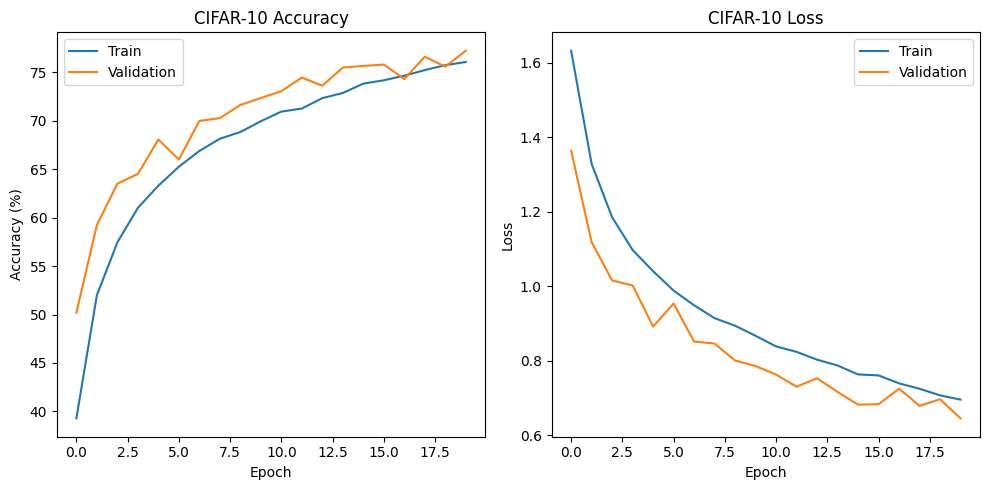

In [22]:
# CIFAR-10 Training and Validation Accuracy Plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(final_train_accuracies, label="Train")
plt.plot(final_val_accuracies, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-10 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_train_losses, label="Train")
plt.plot(final_val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CIFAR-10 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# Final evaluation of the tuned model on the test dataset

test_loss, test_acc = evaluate(
    final_model,
    test_loader,
    criterion
)

print(f"Final CIFAR-10 Test Accuracy: {test_acc:.2f}%")

Final CIFAR-10 Test Accuracy: 78.79%


## CIFAR-10 Results Summary

The CNN model was trained on the CIFAR-10 dataset.

Hyperparameters were tuned using validation accuracy, and the best configuration was selected for final training.

The final model performance is evaluated using the test dataset, which contains unseen images.

In [24]:
# Store CIFAR-10 final results

cifar10_results = {
    "Dataset": "CIFAR-10",
    "Best Learning Rate": learning_rate,
    "Best Weight Decay": weight_decay,
    "Test Accuracy": test_acc
}

cifar10_results

{'Dataset': 'CIFAR-10',
 'Best Learning Rate': 0.001,
 'Best Weight Decay': 0,
 'Test Accuracy': 78.79}

# CIFAR-100 Classification

CIFAR-100 contains 100 classes instead of 10. It contains 100 fine-grained classes grouped into categories such as animals, vehicles, and objects.

The images are still:
- RGB
- 32 × 32 pixels

However, the model has to learn more fine-grained differences between classes, making the task more challenging.

The same CNN architecture is reused, but the final classification layer is changed to output 100 classes.

In [25]:
# Define image transformations
# The same transformation pipeline is used for CIFAR-10 and CIFAR-100 so that the comparison between datasets is fair

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])

In [26]:
# Loading CIFAR-100 dataset

cifar100_train = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

cifar100_test = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("CIFAR-100 loaded")
print("Training samples:", len(cifar100_train))
print("Test samples:", len(cifar100_test))

CIFAR-100 loaded
Training samples: 50000
Test samples: 10000


In [27]:
# Splitting CIFAR-100 training data into:
# - 80% training data
# - 20% validation data

train_size = int(0.8 * len(cifar100_train))
val_size = len(cifar100_train) - train_size

cifar100_train_dataset, cifar100_val_dataset = random_split(
    cifar100_train,
    [train_size, val_size]
)

print("Training samples:", len(cifar100_train_dataset))
print("Validation samples:", len(cifar100_val_dataset))
print("Test samples:", len(cifar100_test))

Training samples: 40000
Validation samples: 10000
Test samples: 10000


In [28]:
# Creating DataLoaders for CIFAR-100

cifar100_train_loader = DataLoader(
    cifar100_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

cifar100_val_loader = DataLoader(
    cifar100_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

cifar100_test_loader = DataLoader(
    cifar100_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("CIFAR-100 DataLoaders ready")

CIFAR-100 DataLoaders ready


In [29]:
# Create CNN model for CIFAR-100

cifar100_model = CNN(num_classes=100).to(device)

print("CIFAR-100 CNN model created")

CIFAR-100 CNN model created


In [30]:
def run_experiment_generic(num_classes, train_loader, val_loader, learning_rate, weight_decay, epochs):

    model = CNN(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    for epoch in range(epochs):
        train_one_epoch(model, train_loader, criterion, optimizer)

    _, val_acc = evaluate(model, val_loader, criterion)

    return val_acc, model

In [31]:
cifar100_experiments = [
    {"lr": 0.001, "weight_decay": 0},      # CIFAR-10's best config
    {"lr": 0.001, "weight_decay": 1e-4},   # Previous config
    {"lr": 0.001, "weight_decay": 1e-3},   # Stronger regularization, in case 100 classes overfits differently
]

cifar100_tuning_results = []

for exp in cifar100_experiments:

    acc, _ = run_experiment_generic(
        num_classes=100,
        train_loader=cifar100_train_loader,
        val_loader=cifar100_val_loader,
        learning_rate=exp["lr"],
        weight_decay=exp["weight_decay"],
        epochs=10
    )

    cifar100_tuning_results.append({
        "learning_rate": exp["lr"],
        "weight_decay": exp["weight_decay"],
        "val_accuracy": acc
    })

cifar100_tuning_results

[{'learning_rate': 0.001, 'weight_decay': 0, 'val_accuracy': 29.13},
 {'learning_rate': 0.001, 'weight_decay': 0.0001, 'val_accuracy': 32.69},
 {'learning_rate': 0.001, 'weight_decay': 0.001, 'val_accuracy': 29.86}]

In [32]:
# Best hyperparameters found for CIFAR-100

cifar100_learning_rate = 0.001
cifar100_weight_decay = 1e-3

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cifar100_model.parameters(),
    lr=cifar100_learning_rate,
    weight_decay=cifar100_weight_decay
)

## CIFAR-100 Model Training

The same CNN architecture is used for CIFAR-100 classification.

The only change is the final output layer, which now produces 100 class scores instead of 10.

Since CIFAR-100 contains more categories and more fine-grained classes, the classification task is more challenging and the expected accuracy is lower than CIFAR-10.

In [33]:
# Training the CIFAR-100 CNN model

cifar100_train_losses = []
cifar100_train_accuracies = []
cifar100_val_losses = []
cifar100_val_accuracies = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        cifar100_model,
        cifar100_train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        cifar100_model,
        cifar100_val_loader,
        criterion
    )

    cifar100_train_losses.append(train_loss)
    cifar100_train_accuracies.append(train_acc)

    cifar100_val_losses.append(val_loss)
    cifar100_val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/20] Train Acc: 6.53% Val Acc: 13.63%
Epoch [2/20] Train Acc: 11.94% Val Acc: 18.10%
Epoch [3/20] Train Acc: 14.72% Val Acc: 21.97%
Epoch [4/20] Train Acc: 16.84% Val Acc: 24.21%
Epoch [5/20] Train Acc: 18.74% Val Acc: 23.86%
Epoch [6/20] Train Acc: 19.62% Val Acc: 27.43%
Epoch [7/20] Train Acc: 21.19% Val Acc: 29.43%
Epoch [8/20] Train Acc: 22.14% Val Acc: 30.53%
Epoch [9/20] Train Acc: 23.18% Val Acc: 29.49%
Epoch [10/20] Train Acc: 24.25% Val Acc: 31.76%
Epoch [11/20] Train Acc: 25.07% Val Acc: 32.70%
Epoch [12/20] Train Acc: 25.91% Val Acc: 34.24%
Epoch [13/20] Train Acc: 26.76% Val Acc: 35.79%
Epoch [14/20] Train Acc: 27.20% Val Acc: 34.29%
Epoch [15/20] Train Acc: 27.71% Val Acc: 36.87%
Epoch [16/20] Train Acc: 29.01% Val Acc: 35.05%
Epoch [17/20] Train Acc: 29.18% Val Acc: 37.58%
Epoch [18/20] Train Acc: 29.71% Val Acc: 38.71%
Epoch [19/20] Train Acc: 30.28% Val Acc: 39.06%
Epoch [20/20] Train Acc: 31.42% Val Acc: 38.50%


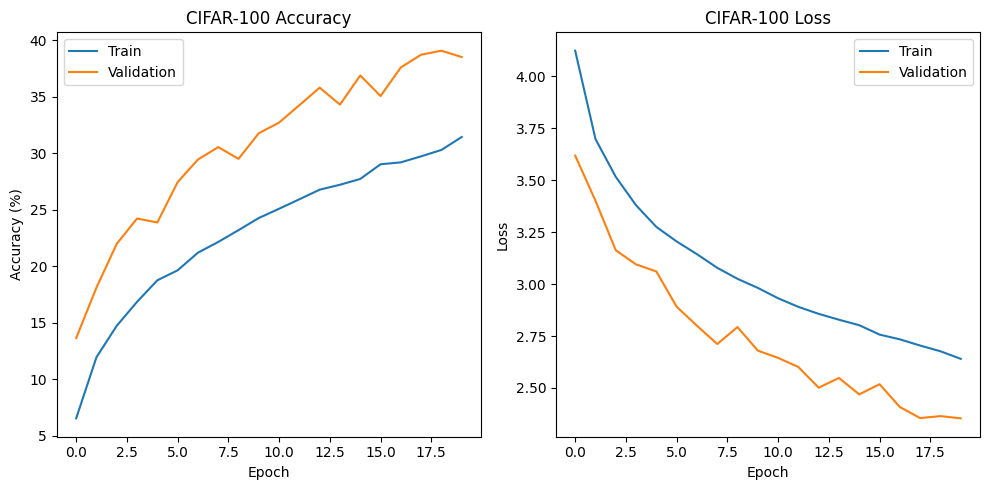

In [34]:
# CIFAR-100 Training and Validation Accuracy Plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(cifar100_train_accuracies, label="Train")
plt.plot(cifar100_val_accuracies, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cifar100_train_losses, label="Train")
plt.plot(cifar100_val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CIFAR-100 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# Final evaluation on CIFAR-100 test data

cifar100_test_loss, cifar100_test_acc = evaluate(
    cifar100_model,
    cifar100_test_loader,
    criterion
)

print(f"CIFAR-100 Test Accuracy: {cifar100_test_acc:.2f}%")

CIFAR-100 Test Accuracy: 38.22%


## CIFAR-100 Results

The CNN model was trained on CIFAR-100 using the same architecture as CIFAR-10.

Since CIFAR-100 contains 100 classes instead of 10, the classification problem is more difficult. The model must learn finer differences between visually similar categories.

The final model performance is evaluated using the test dataset.

In [36]:
# Store CIFAR-100 final results

cifar100_results = {
    "Dataset": "CIFAR-100",
    "Best Learning Rate": cifar100_learning_rate,
    "Best Weight Decay": cifar100_weight_decay,
    "Test Accuracy": cifar100_test_acc
}

cifar100_results

{'Dataset': 'CIFAR-100',
 'Best Learning Rate': 0.001,
 'Best Weight Decay': 0.001,
 'Test Accuracy': 38.22}

#Performance Comparison

In [37]:
import pandas as pd

results_summary = pd.DataFrame([
    cifar10_results,
    cifar100_results
])

results_summary

,Dataset,Best Learning Rate,Best Weight Decay,Test Accuracy
0,CIFAR-10,0.001,0.000,78.79
1,CIFAR-100,0.001,0.001,38.22


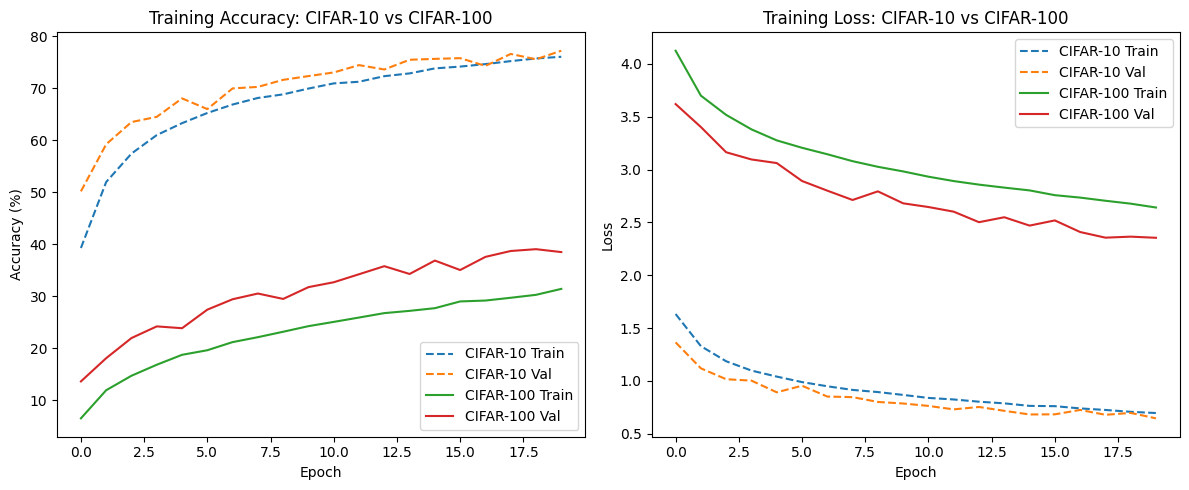

In [38]:
# Side-by-side comparison: CIFAR-10 vs CIFAR-100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
axes[0].plot(final_train_accuracies, label="CIFAR-10 Train", linestyle="--")
axes[0].plot(final_val_accuracies, label="CIFAR-10 Val", linestyle="--")
axes[0].plot(cifar100_train_accuracies, label="CIFAR-100 Train")
axes[0].plot(cifar100_val_accuracies, label="CIFAR-100 Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Training Accuracy: CIFAR-10 vs CIFAR-100")
axes[0].legend()

# Loss comparison
axes[1].plot(final_train_losses, label="CIFAR-10 Train", linestyle="--")
axes[1].plot(final_val_losses, label="CIFAR-10 Val", linestyle="--")
axes[1].plot(cifar100_train_losses, label="CIFAR-100 Train")
axes[1].plot(cifar100_val_losses, label="CIFAR-100 Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training Loss: CIFAR-10 vs CIFAR-100")
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

A CNN model was successfully trained on CIFAR-10 and CIFAR-100 datasets.

The model performance was improved by tuning hyperparameters such as learning rate and weight decay.

CIFAR-10 achieved higher accuracy because it contains fewer and more distinct classes.

CIFAR-100 achieved lower accuracy because it contains more classes and requires the model to learn more detailed visual differences.